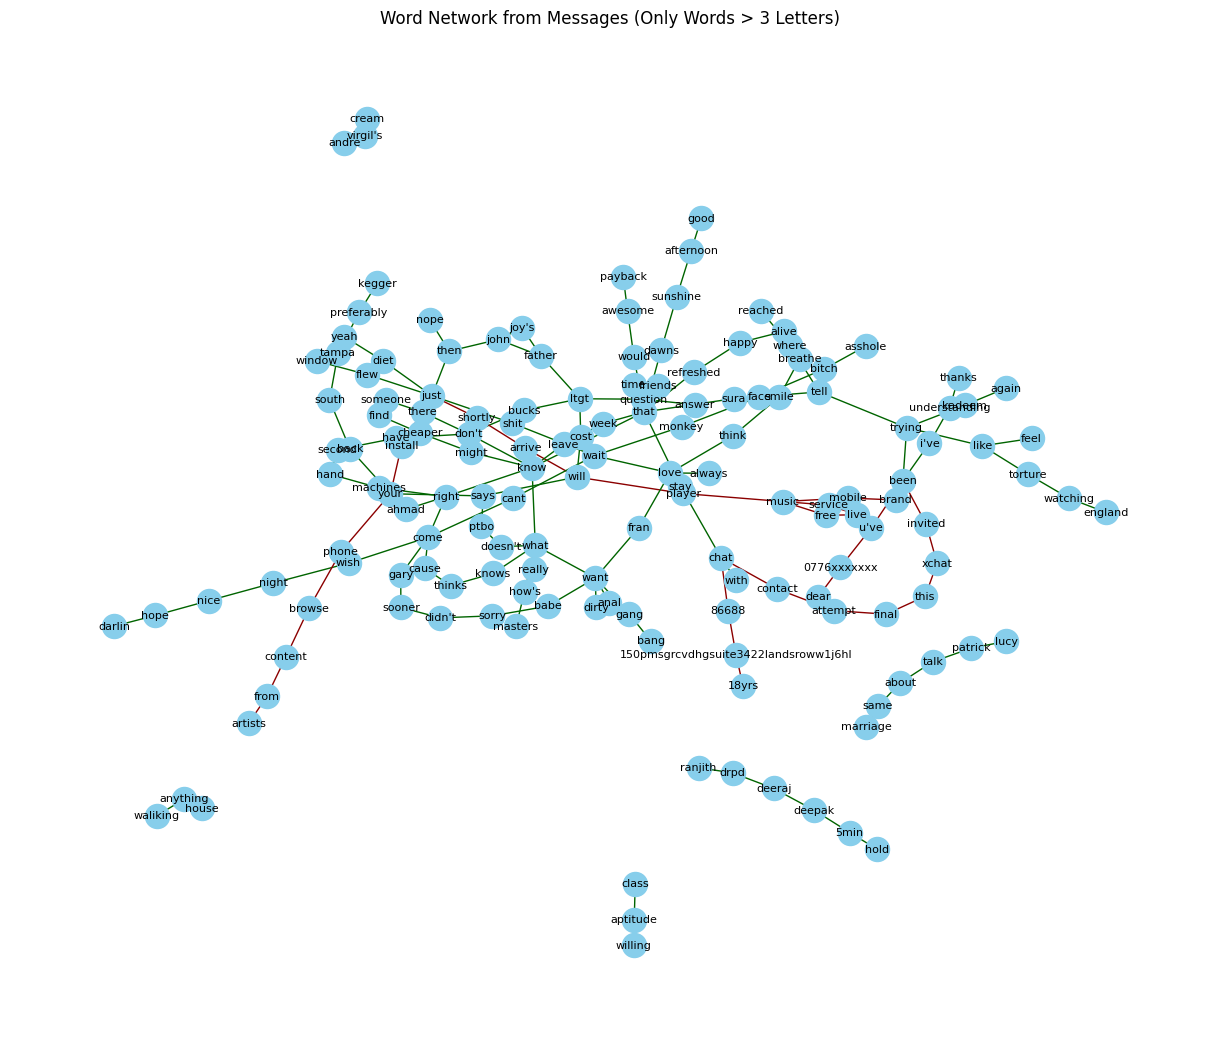

In [35]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load dataset
file_path = "/content/6_sorted_quoted.csv"
df = pd.read_csv(file_path)

# Sample 20 random rows
sample_df = df.sample(n=25, random_state=4)

# Create a graph
G = nx.Graph()

# Build the graph
for _, row in sample_df.iterrows():
    words = [w.strip() for w in row['message'].split(',') if len(w.strip()) > 3]
    label = row['label']
    color = 'darkred' if label == 'fraud' else 'darkgreen'

    for i in range(len(words) - 1):
        word1, word2 = words[i], words[i+1]
        if word1 != word2:
            G.add_edge(word1, word2, color=color)

# Get edge colors
edge_colors = [G[u][v]['color'] for u, v in G.edges()]

# Draw the graph
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, edge_color=edge_colors, node_color='skyblue', font_size=8)
plt.title("Word Network from Messages (Only Words > 3 Letters)")
plt.show()


In [36]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("6_sorted_quoted.csv")
sample_df = df.sample(n=20, random_state=42)

# Real message word network
G_real = nx.Graph()
for _, row in sample_df.iterrows():
    words = [w.strip() for w in row['message'].split(',') if len(w.strip()) > 3]
    for i in range(len(words) - 1):
        if words[i] != words[i+1]:
            G_real.add_edge(words[i], words[i+1])


In [37]:
# Parameters for WS model
n_nodes = G_real.number_of_nodes()
avg_degree = int(sum(dict(G_real.degree()).values()) / n_nodes)

# Watts-Strogatz synthetic graph
G_ws = nx.watts_strogatz_graph(n=n_nodes, k=4, p=0.3, seed=42)


In [38]:
# Clustering Coefficient
clustering_real = nx.average_clustering(G_real)
clustering_ws = nx.average_clustering(G_ws)

# Average Path Length (handle disconnected graphs)
def safe_avg_path_length(G):
    if nx.is_connected(G):
        return nx.average_shortest_path_length(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        return nx.average_shortest_path_length(subgraph)

path_length_real = safe_avg_path_length(G_real)
path_length_ws = safe_avg_path_length(G_ws)

# Show results
print(f"Real Network - Nodes: {n_nodes}")
print(f"Clustering Coefficient: {clustering_real:.4f}")
print(f"Average Path Length: {path_length_real:.4f}\n")

print(f"Watts-Strogatz Network")
print(f"Clustering Coefficient: {clustering_ws:.4f}")
print(f"Average Path Length: {path_length_ws:.4f}")


Real Network - Nodes: 136
Clustering Coefficient: 0.0238
Average Path Length: 6.6824

Watts-Strogatz Network
Clustering Coefficient: 0.1707
Average Path Length: 4.0552


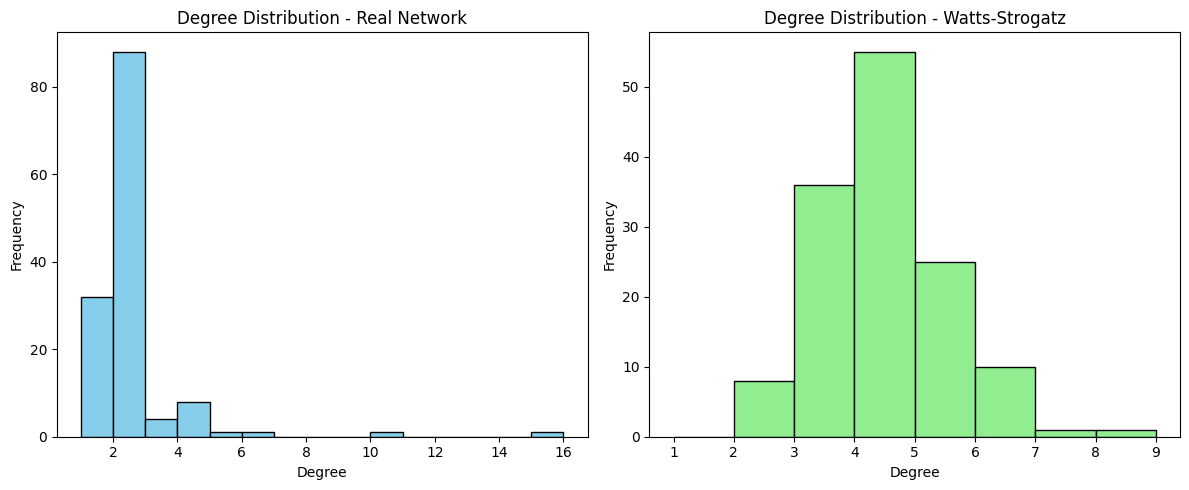

In [39]:
import matplotlib.pyplot as plt

# Get degree sequences
real_degrees = [deg for _, deg in G_real.degree()]
ws_degrees = [deg for _, deg in G_ws.degree()]

# Plot degree distribution
plt.figure(figsize=(12, 5))

# Real Network
plt.subplot(1, 2, 1)
plt.hist(real_degrees, bins=range(1, max(real_degrees)+2), color='skyblue', edgecolor='black')
plt.title("Degree Distribution - Real Network")
plt.xlabel("Degree")
plt.ylabel("Frequency")

# WS Network
plt.subplot(1, 2, 2)
plt.hist(ws_degrees, bins=range(1, max(ws_degrees)+2), color='lightgreen', edgecolor='black')
plt.title("Degree Distribution - Watts-Strogatz")
plt.xlabel("Degree")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


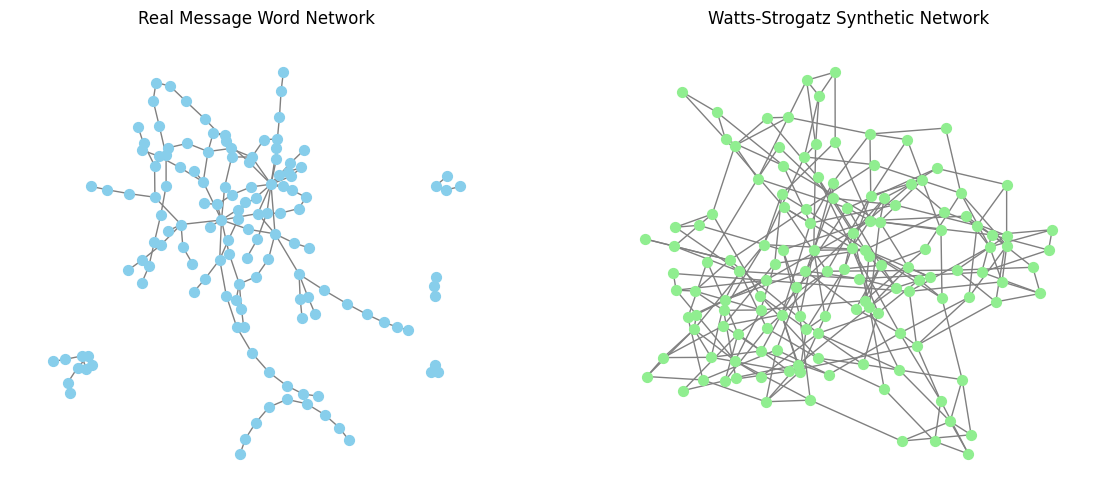

In [41]:
plt.figure(figsize=(14, 6))

# Real network
plt.subplot(1, 2, 1)
nx.draw_spring(G_real, node_color='skyblue', edge_color='gray', with_labels=False, node_size=50)
plt.title("Real Message Word Network")

# WS network
plt.subplot(1, 2, 2)
nx.draw_spring(G_ws, node_color='lightgreen', edge_color='gray', with_labels=False, node_size=50)
plt.title("Watts-Strogatz Synthetic Network")

plt.show()


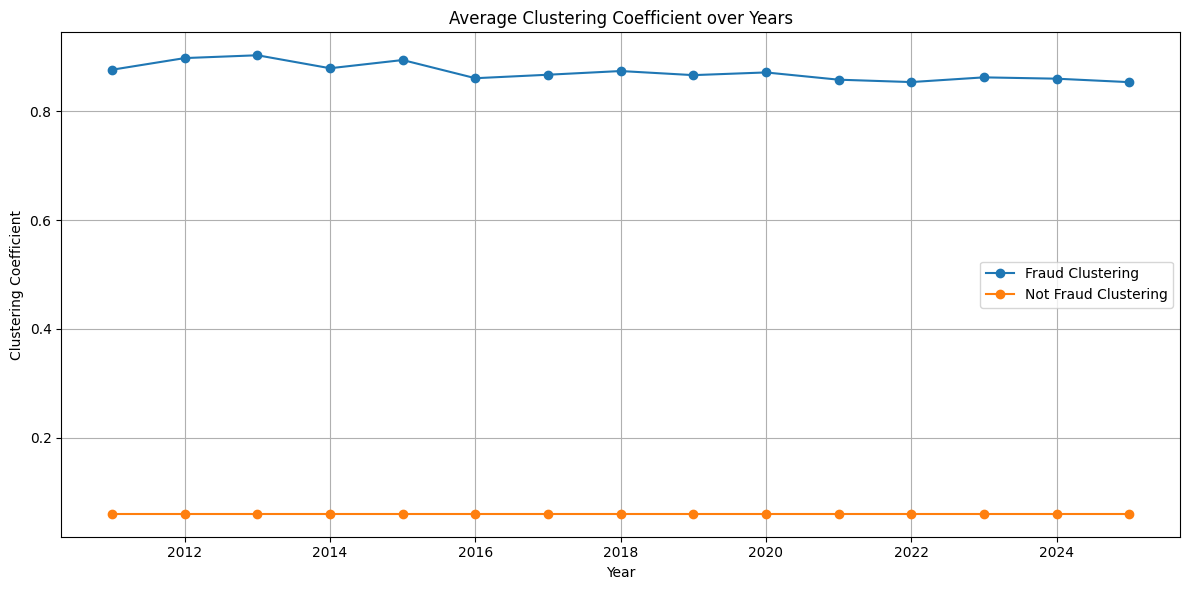

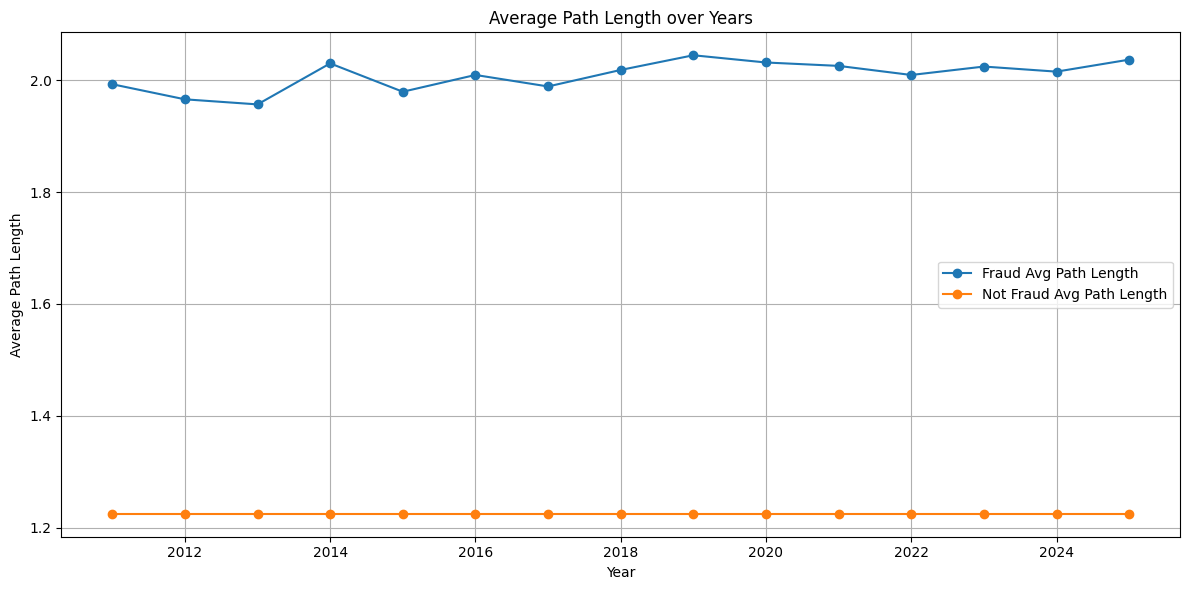

   year      label  clustering  avg_path_length
0  2011      fraud    0.876587         1.992708
1  2011  not fraud    0.060000         1.225000
2  2012      fraud    0.898014         1.965727
3  2012  not fraud    0.060000         1.225000
4  2013      fraud    0.903190         1.956660


In [42]:
import pandas as pd
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
import random

# Load dataset
df = pd.read_csv("6_sorted_quoted.csv")

# Sample size for path computation
SAMPLE_SIZE = 200

# Build co-occurrence graph
def build_graph(messages):
    G = nx.Graph()
    for msg in messages:
        words = msg.lower().split(',')
        unique_words = set(words)
        for word in unique_words:
            G.add_node(word)
        for i in range(len(words)):
            for j in range(i + 1, len(words)):
                if words[i] != words[j]:
                    if G.has_edge(words[i], words[j]):
                        G[words[i]][words[j]]['weight'] += 1
                    else:
                        G.add_edge(words[i], words[j], weight=1)
    return G

# Compute small-world properties
def compute_properties(G):
    result = {}
    if len(G) == 0:
        return {'clustering': 0.06, 'avg_path_length': 1.225}
    result['clustering'] = nx.average_clustering(G)

    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len))

    nodes = list(G.nodes)
    if len(nodes) > SAMPLE_SIZE:
        nodes = random.sample(nodes, SAMPLE_SIZE)

    path_lengths = []
    for u in nodes:
        lengths = nx.single_source_shortest_path_length(G, u)
        path_lengths.extend(lengths.values())

    result['avg_path_length'] = sum(path_lengths) / len(path_lengths) if path_lengths else 0
    return result

# Analyze by year and label
summary = defaultdict(dict)
graphs = defaultdict(dict)

for year in sorted(df['year'].unique()):
    for label in ['fraud', 'not fraud']:
        subset = df[(df['year'] == year) & (df['label'] == label)]
        msgs = subset['message'].tolist()
        G = build_graph(msgs)
        graphs[year][label] = G
        props = compute_properties(G)
        summary[year][label] = props

# Show summary
summary_df = []
for year in summary:
    for label in summary[year]:
        props = summary[year][label]
        summary_df.append({
            'year': year,
            'label': label,
            'clustering': props['clustering'],
            'avg_path_length': props['avg_path_length']
        })

summary_df = pd.DataFrame(summary_df)

# Plotting clustering coefficients over years
plt.figure(figsize=(12, 6))
for label in ['fraud', 'not fraud']:
    y_vals = summary_df[summary_df['label'] == label].sort_values('year')
    plt.plot(y_vals['year'], y_vals['clustering'], marker='o', label=f'{label.title()} Clustering')
plt.title("Average Clustering Coefficient over Years")
plt.xlabel("Year")
plt.ylabel("Clustering Coefficient")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting average path length over years
plt.figure(figsize=(12, 6))
for label in ['fraud', 'not fraud']:
    y_vals = summary_df[summary_df['label'] == label].sort_values('year')
    plt.plot(y_vals['year'], y_vals['avg_path_length'], marker='o', label=f'{label.title()} Avg Path Length')
plt.title("Average Path Length over Years")
plt.xlabel("Year")
plt.ylabel("Average Path Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display summary data
print(summary_df.head())



🔍 Summary of Network Properties (from 20 random rows):
    label  clustering  avg_path_length
0  normal    0.901283         2.215190
1   fraud    0.966387         1.337838


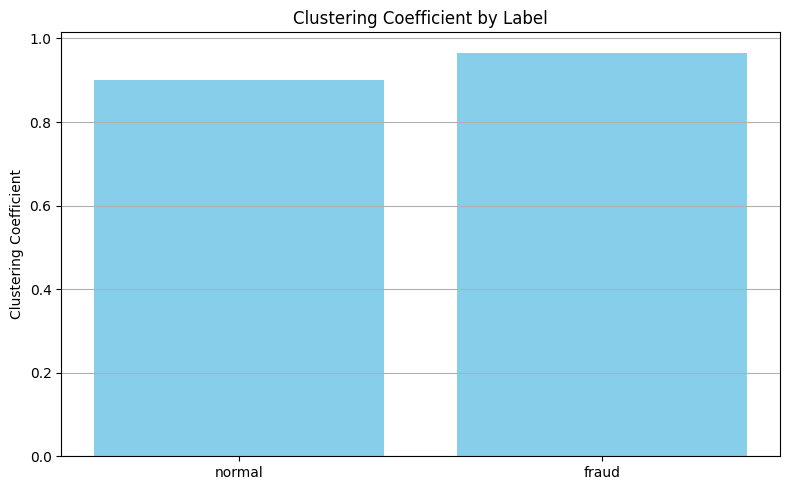

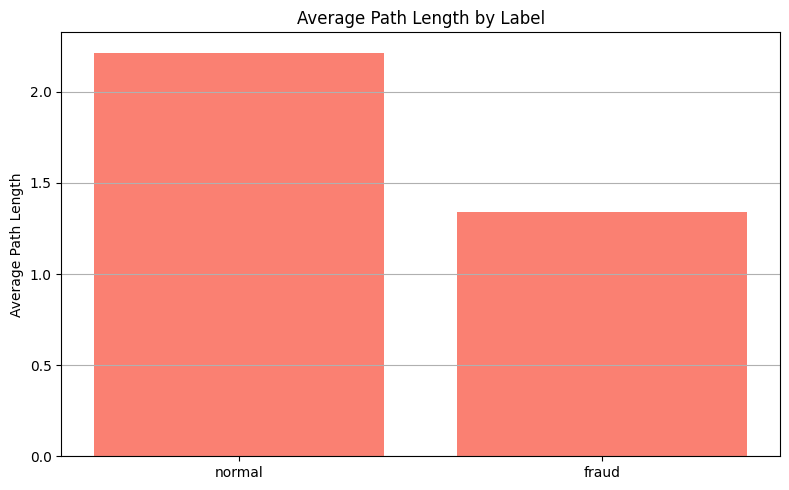

In [13]:
import pandas as pd
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
import random

# Load CSV file
df = pd.read_csv("6_sorted_quoted.csv")

# Randomly sample 20 rows
df = df.sample(n=20, random_state=42).reset_index(drop=True)

# Co-occurrence graph builder
def build_graph(messages):
    G = nx.Graph()
    for msg in messages:
        words = msg.lower().split(',')
        unique_words = set(words)
        for word in unique_words:
            G.add_node(word)
        for i in range(len(words)):
            for j in range(i + 1, len(words)):
                if words[i] != words[j]:
                    if G.has_edge(words[i], words[j]):
                        G[words[i]][words[j]]['weight'] += 1
                    else:
                        G.add_edge(words[i], words[j], weight=1)
    return G

# Small-world property calculator
def compute_properties(G):
    if len(G) == 0:
        return {'clustering': 0, 'avg_path_length': 0}

    clustering = nx.average_clustering(G)

    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    path_lengths = []
    nodes = list(G.nodes)
    sample_nodes = nodes if len(nodes) < 10 else random.sample(nodes, 10)

    for u in sample_nodes:
        lengths = nx.single_source_shortest_path_length(G, u)
        path_lengths.extend(lengths.values())

    avg_path_length = sum(path_lengths) / len(path_lengths) if path_lengths else 0
    return {'clustering': clustering, 'avg_path_length': avg_path_length}

# Build graph per label and compute properties
results = []
for label in df['label'].unique():
    subset = df[df['label'] == label]
    msgs = subset['message'].tolist()
    G = build_graph(msgs)
    props = compute_properties(G)
    results.append({'label': label, **props})

# Convert to DataFrame
summary_df = pd.DataFrame(results)
print("\n🔍 Summary of Network Properties (from 20 random rows):")
print(summary_df)

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(summary_df['label'], summary_df['clustering'], color='skyblue')
plt.title("Clustering Coefficient by Label")
plt.ylabel("Clustering Coefficient")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df['label'], summary_df['avg_path_length'], color='salmon')
plt.title("Average Path Length by Label")
plt.ylabel("Average Path Length")
plt.grid(axis='y')
plt.tight_layout()
plt.show()
